# Step 1 : Import Required Libraries

In [93]:
import joblib
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

In [94]:
# ==========================================================
# Step 2 : Load Dataset
# ==========================================================

import pandas as pd

# Load Dataset
df = pd.read_csv("data/cardekho_dataset.csv")

# Drop unnecessary columns
df.drop(columns=["Unnamed: 0", "car_name"], inplace=True)

# ----------------------------------------------------------
# Dataset Preview
# ----------------------------------------------------------
print("=" * 60)
print("First 5 Rows")
print("=" * 60)
display(df.head())

# ----------------------------------------------------------
# Dataset Shape
# ----------------------------------------------------------
print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(df.shape)

# ----------------------------------------------------------
# Column Names
# ----------------------------------------------------------
print("=" * 60)
print("Columns")
print("=" * 60)
print(df.columns.tolist())

# ----------------------------------------------------------
# Dataset Information
# ----------------------------------------------------------
print("=" * 60)
print("Dataset Information")
print("=" * 60)
df.info()

# ----------------------------------------------------------
# Missing Values
# ----------------------------------------------------------
print("=" * 60)
print("Missing Values")
print("=" * 60)
display(df.isnull().sum().to_frame(name="Missing Values"))

# ----------------------------------------------------------
# Numerical Summary
# ----------------------------------------------------------
print("=" * 60)
print("Numerical Summary")
print("=" * 60)
display(df.describe().round(2))

First 5 Rows


,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


Dataset Shape
(15411, 12)
Columns
['brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              15411 non-null  str    
 1   model              15411 non-null  str    
 2   vehicle_age        15411 non-null  int64  
 3   km_driven          15411 non-null  int64  
 4   seller_type        15411 non-null  str    
 5   fuel_type          15411 non-null  str    
 6   transmission_type  15411 non-null  str    
 7   mileage            15411 non-null  float64
 8   engine             15411 non-null  int64  
 9   max_power          15411 non-null  float64
 10  seats              15411 non-null  int64  
 11  selling_price      15411 non-null  int64  
dtypes: float64(2), 

,Missing Values
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0
engine,0
max_power,0


Numerical Summary


,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.00,15411.00,15411.00,15411.00,15411.00,15411.00,15411.00
mean,6.04,55616.48,19.70,1486.06,100.59,5.33,774971.12
std,3.01,51618.55,4.17,521.11,42.97,0.81,894128.36
min,0.00,100.00,4.00,793.00,38.40,0.00,40000.00
25%,4.00,30000.00,17.00,1197.00,74.00,5.00,385000.00
50%,6.00,50000.00,19.67,1248.00,88.50,5.00,556000.00
75%,8.00,70000.00,22.70,1582.00,117.30,5.00,825000.00
max,29.00,3800000.00,33.54,6592.00,626.00,9.00,39500000.00


In [95]:
# ==========================================================
# Step 3 : Feature Selection
# ==========================================================

# Features (X)
X = df.drop(columns=["selling_price"])

# Target (y)
y = df["selling_price"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

display(X.head())

Features Shape : (15411, 11)
Target Shape : (15411,)


,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5


In [96]:
# ==========================================================
# Step 4 : Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)


Training Data : (12328, 11)
Testing Data  : (3083, 11)


In [97]:
# ==========================================================
# Step 5 : Feature Categories
# ==========================================================

numeric_features = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

categorical_features = [
    "brand",
    "model",
    "seller_type",
    "fuel_type",
    "transmission_type"
]

print("Numeric Features")
print(numeric_features)

print("\nCategorical Features")
print(categorical_features)

Numeric Features
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

Categorical Features
['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']


In [98]:
# ==========================================================
# Step 6 : Preprocessing Pipeline
# ==========================================================

# Numeric Pipeline
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical Pipeline
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine both pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("✅ Preprocessing Pipeline Created Successfully!")

✅ Preprocessing Pipeline Created Successfully!


In [ ]:
# ==========================================================
# Step 7 : Create & Train Model
# ==========================================================

# Final Pipeline
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor",RandomForestRegressor(
                    n_estimators=200,
                    max_depth=20,
                    min_samples_split=5,
                    min_samples_leaf=2,
                    random_state=42,
                    n_jobs=-1
        ))
    ]
)

print("Training Model...")

# Train Model
model.fit(X_train, y_train)

print("✅ Model Trained Successfully!")

In [73]:
# ==========================================================
# Step 8 : Evaluate Model
# ==========================================================

# Prediction on Test Data
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 50)
print("📊 MODEL PERFORMANCE")
print("=" * 50)

print(f"R² Score  : {r2:.4f}")
print(f"MAE       : ₹ {mae:,.2f}")
print(f"RMSE      : ₹ {rmse:,.2f}")

print("=" * 50)

📊 MODEL PERFORMANCE
R² Score  : 0.9331
MAE       : ₹ 100,096.84
RMSE      : ₹ 224,376.51


In [75]:
# ==========================================================
# Step 9 : Actual vs Predicted
# ==========================================================

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

# Difference
results["Difference"] = (
    results["Actual Price"] -
    results["Predicted Price"]
)

# Round values
results["Predicted Price"] = results["Predicted Price"].round(0).astype(int)
results["Difference"] = results["Difference"].round(0).astype(int)

# Reset index
results = results.reset_index(drop=True)

# Show first 15 rows
display(results.head(15))

,Actual Price,Predicted Price,Difference
0,190000,246225,-56225
1,600000,652270,-52270
2,665000,640005,24995
3,1570000,1249134,320866
4,160000,183888,-23888
5,675000,422649,252351
6,465000,474937,-9937
7,260000,292340,-32340
8,300000,354592,-54592
9,850000,1210754,-360754


In [76]:
# ==========================================================
# Step 10 : Feature Importance
# ==========================================================

# Extract trained Random Forest
rf = model.named_steps["regressor"]

# Feature Names after OneHotEncoding
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(20))

,Feature,Importance
4,num__max_power,0.742078
0,num__vehicle_age,0.136015
1,num__km_driven,0.044930
3,num__engine,0.021789
2,num__mileage,0.016467
26,cat__brand_Mercedes-Benz,0.004079
20,cat__brand_Land Rover,0.003012
114,cat__model_Rover,0.002955
5,num__seats,0.001770
40,cat__model_7,0.001345


In [77]:
# ==========================================================
# Step 11 : Save Model
# ==========================================================

import os

os.makedirs("model", exist_ok=True)

joblib.dump(
    model,
    "model/car_price_model.joblib"
)

print("✅ Model Saved Successfully!")

✅ Model Saved Successfully!


In [78]:
# ==========================================================
# Step 12 : Test Saved Model
# ==========================================================

loaded_model = joblib.load(
    "model/car_price_model.joblib"
)

print("✅ Model Loaded Successfully!")

✅ Model Loaded Successfully!


In [79]:
# ==========================================================
# Step 13 : Sample Prediction
# ==========================================================

sample = pd.DataFrame({
    "brand": ["Maruti"],
    "model": ["Alto"],
    "vehicle_age": [5],
    "km_driven": [35000],
    "seller_type": ["Dealer"],
    "fuel_type": ["Petrol"],
    "transmission_type": ["Manual"],
    "mileage": [22.0],
    "engine": [998],
    "max_power": [67.1],
    "seats": [5]
})

prediction = loaded_model.predict(sample)

print(
    f"Predicted Selling Price : ₹ {prediction[0]:,.0f}"
)

Predicted Selling Price : ₹ 324,727


In [87]:
# ==========================================================
# Step 14 : 5-Fold Cross Validation
# ==========================================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("=" * 50)
print("5-Fold Cross Validation")
print("=" * 50)

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i:<2}: {score:.4f}")

print("=" * 50)
print(f"Average R² Score      : {cv_scores.mean():.4f}")
print(f"Standard Deviation    : {cv_scores.std():.4f}")
print("=" * 50)

5-Fold Cross Validation
Fold 1 : 0.9297
Fold 2 : 0.7398
Fold 3 : 0.9287
Fold 4 : 0.8614
Fold 5 : 0.9246
Average R² Score      : 0.8769
Standard Deviation    : 0.0732


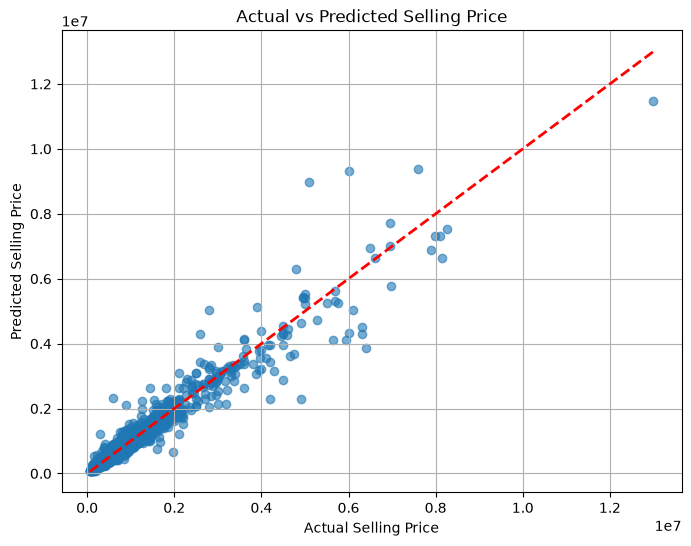

In [88]:
# ==========================================================
# Step 15 : Actual vs Predicted Scatter Plot
# ==========================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.grid(True)

plt.show()

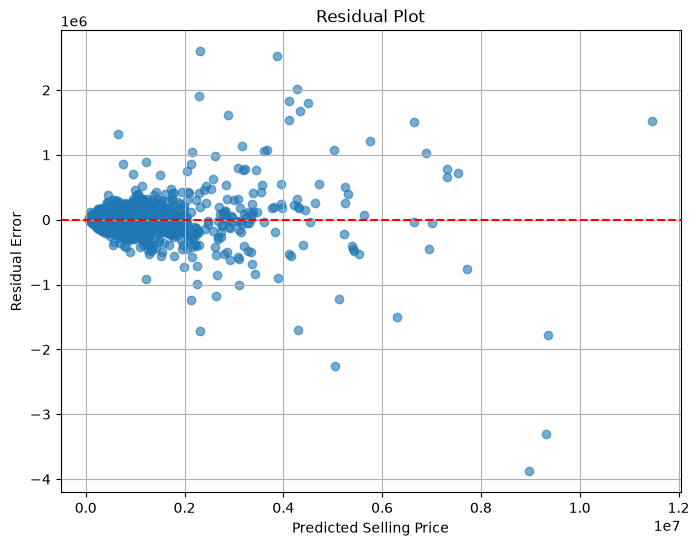

In [89]:
# ==========================================================
# Step 16 : Residual Plot
# ==========================================================

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual Error")
plt.title("Residual Plot")

plt.grid(True)

plt.show()

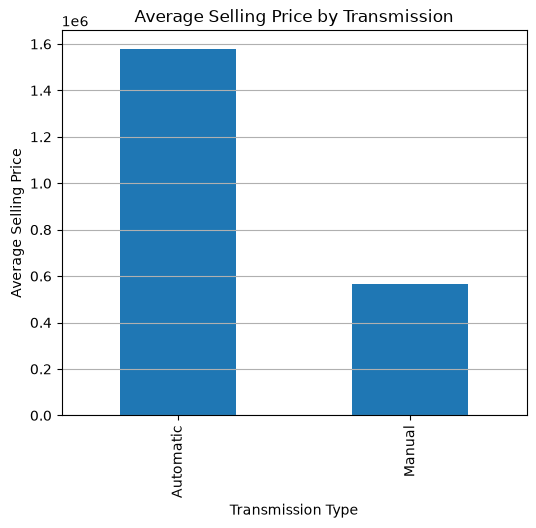

In [90]:
# ==========================================================
# Step 17 : Automatic vs Manual Price
# ==========================================================

import matplotlib.pyplot as plt

avg_price = df.groupby("transmission_type")["selling_price"].mean()

plt.figure(figsize=(6,5))

avg_price.plot(kind="bar")

plt.title("Average Selling Price by Transmission")
plt.xlabel("Transmission Type")
plt.ylabel("Average Selling Price")

plt.grid(axis="y")

plt.show()

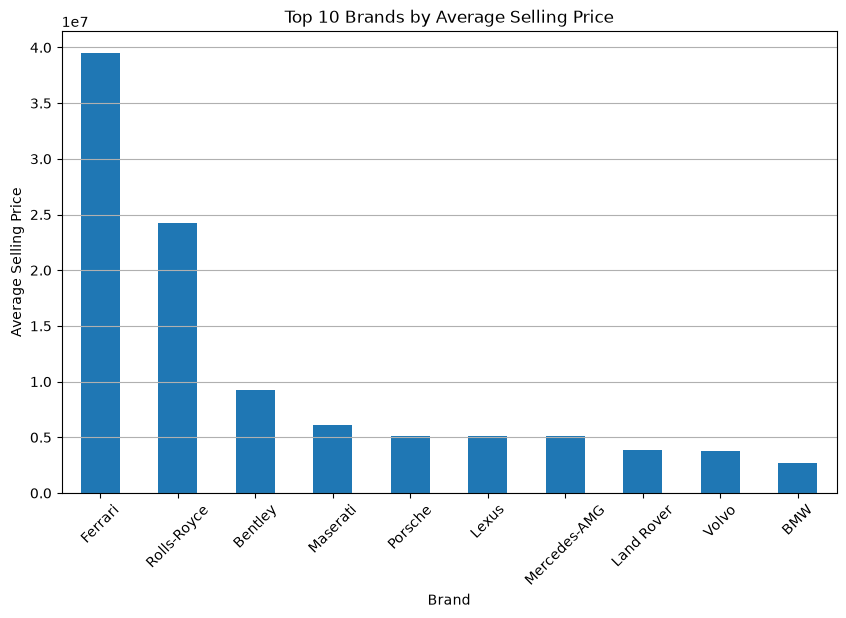

In [91]:
# ==========================================================
# Step 18 : Average Selling Price by Brand
# ==========================================================

brand_price = (
    df.groupby("brand")["selling_price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

brand_price.plot(kind="bar")

plt.title("Top 10 Brands by Average Selling Price")
plt.xlabel("Brand")
plt.ylabel("Average Selling Price")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

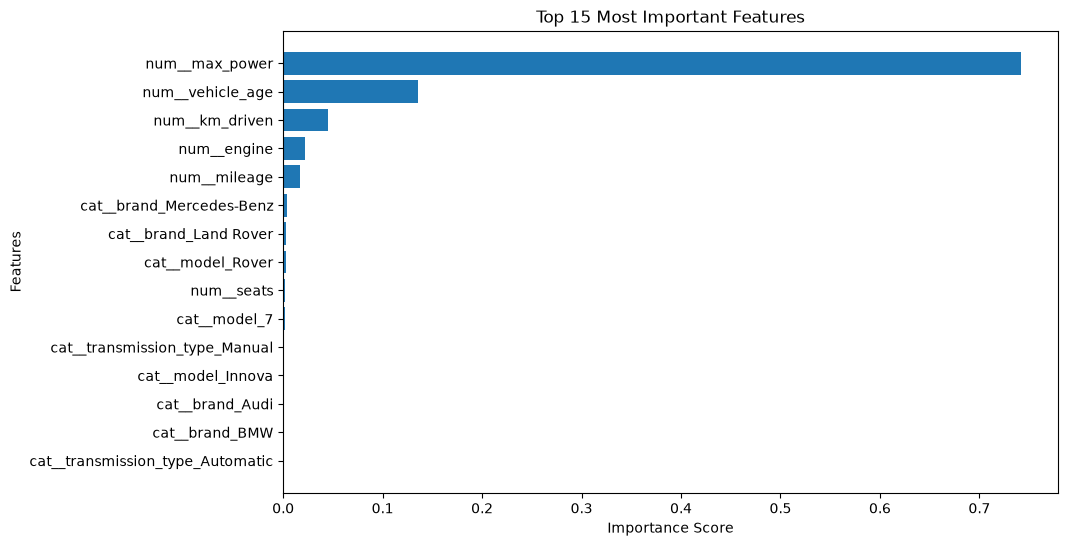

In [92]:
# ==========================================================
# Step 19 : Feature Importance Graph
# ==========================================================

top_features = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 15 Most Important Features")

plt.gca().invert_yaxis()

plt.show()